# Introduction
In the world of hospitality, customer reviews are key to improving products and providing a better customer experience. However, with thousands of reviews scattered across various platforms, it is hard for businesses to make sense of them all.

This project develops an intelligent pipeline that processes text reviews and outputs a structured, grounded summary—powered by RAG, embeddings, one-shot prompting, and text understanding.

The Smart Review Summarizer consists of:

# Phase 1 (By April 20th ) - Gen AI capabilities incorporated
    1.Structured Output/JSON Model: The current program stores the structured JSON data in an output file.
    2.Document Understanding: The program currently reads reviews from a sample dataset created in an Excel file.
    3.Embeddings: Sentence transformers are used in this project, specifically the all-miniLM-L6-v2 model.
    4.Retrieval-Augmented Generation (RAG): Using the FLAN-T5 model to generate relevant summaries by retrieving passages from the vector store based on the query.
    5.Vector Store: FAISS index.
    6.Classification of Reviews: Reviews are categorized based on several attributes: cleanliness, location, value, service, maintenance, attractions, food availability,  
      attraction, queue fairness, and overall experience.

# 🚀 Phase 2 – Future Product Enhancements
    1. 💬 Semantic Clustering of Reviews
    Group semantically similar reviews before summarizing to improve coherence and reduce redundancy in the output.
    2. 🤖 Intelligent Agents for Real-Time Insights
    Integrate agents (e.g., LangChain, OpenAI tools) to fetch and summarize live reviews from platforms like TripAdvisor or Booking.com using APIs.
    3. 🔁 MLOps Integration
    Incorporate CI/CD, model versioning, and performance monitoring to productionize the pipeline using tools like MLflow or SageMaker.
    4. 🌐 Streamlit Interface for Live Demos
    Build a user-friendly UI for real-time input, output display, and visualization using Streamlit or Gradio.
    5. 🌎 Multilingual Support
    Expand the model to handle reviews in multiple languages using translation APIs or multilingual models (e.g., mbart, NLLB).


# GitHub

https://github.com/prakashpillai/LearningGenAI.git

# Use Case
Imagine a hotel manager trying to understand guest feedback from Booking.com, Google reviews, and TripAdvisor messages. Instead of manually reading through hundreds of reviews, our system:

    1.Summarizes guest experiences (e.g., cleanliness, location, service, value, etc.)
    2.Categorizes pros and cons from real reviews
    3.Grounds summaries in similar past reviews using RAG (Retrieval-Augmented Generation)

## 🔍 Try It Yourself

Use the cell below to run your own custom query (e.g., `"Tell me what guests think about cleanliness"`).

In [224]:
query = "Tell me what guests think about guest experience in disneyland Paris"

# Step 1 : Install required libraries

In [225]:
# Install the required libraries for embedding text,Hugging face core library
!pip install -q sentence-transformers transformers faiss-cpu scikit-learn pandas matplotlib ipython

# Step 2 : Importing the required libraries and logger setup

In [226]:
import json
import re
import csv
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from transformers import T5Tokenizer, T5ForConditionalGeneration
# for fast vector similarity search
import faiss
from transformers import pipeline

# for visualization of grounded summary
from collections import Counter
import warnings
from matplotlib import font_manager
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import logging

In [227]:

# loading the configuration file 
with open("/kaggle/input/config/config.json") as f:
    CONFIG = json.load(f)

DEBUG = CONFIG.get("debug", False)

# Clean up existing handlers in notebook environments
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

# Configure logging
logging.basicConfig(
    filename='debug_logs.log',       # Log file saved in Kaggle environment
    level=logging.DEBUG if DEBUG else logging.INFO,  # Change to DEBUG or WARNING as needed
    format='[%(levelname)s] %(asctime)s - %(message)s',
    filemode='w'  
)
# Create logger instance
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG if DEBUG else logging.INFO)


### Step 3 : Load a sample Dataset from Excel
Creating a simple dataset of reviews using Excel and uploaded the file in the dataset.Reading the excel using Pandas.

In [228]:
# Load the Excel file containing user reviews
# Remove any rows with missing review text to ensure clean input
# Extract reviews as a list
#loading sample data from file in the pandas dataframe.
df = pd.read_excel('/kaggle/input/test-data/Dataset_Kaggle_project.xlsx', engine='openpyxl')
#Removes rows with missing values
df = df.dropna(subset=["Review"])
texts = df['Review'].tolist()
df.head()


,Review,Scoring
0,Absolutely fantastic,5
1,"Absolutely magical, our grandchildren were tot...",5
2,After spending hours standing in the long over...,1
3,Best place on earth,5
4,Cool,5


# Step 4: Load the pre-trained model

In [229]:
# Load SentenceTransformer model for embeddings
# Load FLAN-T5 for prompt-based text generation (cluster labeling)
model_name = 'google/flan-t5-large'
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

Generate text embeddings for each review using pre-trained model and store them in a FAISS vector database.

# Step 5 # Create the embeddings and index for similarity search (FAISS index)

In [230]:
embeddings = embed_model.encode(texts, show_progress_bar=True)
dimension = embeddings.shape[1]
# Build a FAISS index for fast similarity querying
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

# Step 6 : Clause level categorization - Text split and preprocessing

In [231]:
# Utility to break down long reviews into shorter, semantically meaningful clauses
# Helps improve clustering and labeling accuracy
def split_review_into_clauses(review):
    raw_clauses = re.split(r'[.!?;]+', review)
    return [c.strip() for c in raw_clauses if len(c.strip().split()) >= 5]

# Step 7: Clause Categorization and sentiment detection

In [232]:
# Load external rule files (uploaded to Kaggle)
with open("/kaggle/input/sentiment-overrides/category_rules.json") as f:
    CATEGORY_RULES = json.load(f)
with open("/kaggle/input/sentiment-overrides/sentiment_overrides.json") as f:
    SENTIMENT_OVERRIDES = json.load(f)

# Load sentiment model
try:
    sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
except:
    print(f"Error loading sentiment model", {e})

    CONFIDENCE_THRESHOLD = 0.6
DEBUG = False  # Toggle debug prints

# Match keywords inside a clause
def match_keywords(clause, keywords):
    return any(k in clause for k in keywords)

def analyze_clause(clause):
    clause = clause.strip().lower()
    entry = {"text": clause, "category_sentiments": {}}

     # Match categories
    for category, keywords in CATEGORY_RULES.items():
        if match_keywords(clause, keywords):
            entry["category_sentiments"][category] = None  # sentiment to be added

    # Sentiment override
    overridden = None
    for label, phrases in SENTIMENT_OVERRIDES.items():
        if match_keywords(clause, phrases):
            overridden = label
            break

    # If no categories matched, assign 'uncategorized'
    if not entry["category_sentiments"]:
        entry["category_sentiments"]["uncategorized"] = None

    # Run sentiment model
    try:
        result = sentiment_model(clause)[0]
        model_label = result["label"].lower()
        score = result["score"]

        sentiment = (
            "neutral" if score < CONFIDENCE_THRESHOLD
            else "positive" if "positive" in model_label
            else "negative" if "negative" in model_label
            else "neutral"
        )
    except Exception as e:
        print(f"Sentiment analysis failed for: {clause}\nError: {e}")
        sentiment = "neutral"

    # Assign sentiment per category
    final_sentiment = overridden if overridden else sentiment
    for cat in entry["category_sentiments"].keys():
        entry["category_sentiments"][cat] = final_sentiment

    return entry


# Categorize a list of reviews
def categorize_reviews_multiclause(review_list):
    categorized = []
    for review in review_list:
        clauses = split_review_into_clauses(review)
        for clause in clauses:
            if clause.strip():
                result = analyze_clause(clause)
                if DEBUG:
                    cat_sent = ", ".join([f"{k}: {v}" for k, v in result["category_sentiments"].items()])
                    print(f"DEBUG → Clause: {clause} → {cat_sent}")
                categorized.append(result)
    return categorized


Device set to use cpu


# Step 8 : Genrate grounded summary and Categorize Top reviews based on query

In [233]:
import logging
import json
from collections import Counter

# Configure logger
logger = logging.getLogger(__name__)

def grounded_summary(query, k, debug):
    # Load config from file
    with open("/kaggle/input/config/config.json") as f:
        CONFIG = json.load(f)

    # Extract debug setting from config
    debug = CONFIG.get("debug", False)

    # Set logging level based on config
    log_level = logging.DEBUG if debug else logging.INFO
    logging.basicConfig(level=log_level, format='[%(levelname)s] %(message)s')

    # Step 1: Retrieve top-k most semantically similar reviews
    query_embedding = embed_model.encode([query])
    D, I = index.search(query_embedding, k)
    top_k_reviews = [texts[i] for i in I[0]]

    if debug:
        logger.debug(f"🔍 Step 1: Top-k {k}  Retrieved Reviews:")
        for i, review in enumerate(top_k_reviews, 1):
            logger.debug(f"{i}. {review}")

    # Step 2: Categorize clauses
    categorized_reviews = categorize_reviews_multiclause(top_k_reviews)

    if debug:
        logger.debug("\n🧩 Step 2: Categorized Clauses:")
        for item in categorized_reviews:
            logger.debug(f"Text: {item['text']}, Category Sentiments: {item.get('category_sentiments', {})}")

    # Step 3: Stats
    all_categories = [
        cat.lower()
        for review in categorized_reviews
        for cat in review["category_sentiments"].keys()
        if cat.lower() != "uncategorized"
    ]

    all_sentiments = [
        sentiment
        for review in categorized_reviews
        for sentiment in review["category_sentiments"].values()
        if sentiment
    ]

    category_counts = Counter(all_categories)
    sentiment_counts = Counter(all_sentiments)

    total_cats = len(all_categories)
    top_categories = category_counts.most_common(3)
    top_categories_str = ", ".join([
        f"{cat} ({(count / total_cats) * 100:.0f}%)" for cat, count in top_categories
    ])

    total_sentiments = len(all_sentiments)
    positive_pct = (sentiment_counts["positive"] / total_sentiments) * 100 if total_sentiments else 0
    negative_pct = (sentiment_counts["negative"] / total_sentiments) * 100 if total_sentiments else 0
    neutral_pct = (sentiment_counts["neutral"] / total_sentiments) * 100 if total_sentiments else 0

    top_sentiment = max(sentiment_counts, key=sentiment_counts.get) if sentiment_counts else "neutral"

    if debug:
        logger.debug("\n📊 Step 3: Stats Summary:")
        logger.debug(f"Top Categories: {top_categories_str}")
        logger.debug(f"Sentiment → Positive: {positive_pct:.0f}%, Neutral: {neutral_pct:.0f}%, Negative: {negative_pct:.0f}%")

    # Step 4: Prepare Summary Input
    positive_clauses = [r["text"] for r in categorized_reviews if "positive" in r["category_sentiments"].values()]
    negative_clauses = [r["text"] for r in categorized_reviews if "negative" in r["category_sentiments"].values()]
    neutral_clauses = [r["text"] for r in categorized_reviews if "neutral" in r["category_sentiments"].values()]

    clauses_to_use = positive_clauses[:5] + negative_clauses[:5] + neutral_clauses[:2]
    review_text = " ".join(clauses_to_use)

    # Optimized prompt
    prompt = (
        "You are summarizing visitor reviews about Disneyland Parks.\n"
        "Summarize what guests liked 👍, disliked 👎, and suggest improvements 🛠️.\n"
        "Use bullet points and avoid repetition.\n\n"
        "Examples:\n"
        "- 👍 Friendly staff, clean rooms, and great location.\n"
        "- 👎 Long wait times and high food prices.\n"
        "- 🛠️ Improve queue management and offer more food variety.\n\n"
        f"Guest comments:\n{review_text}\n\n"
        "Summary:"
    )

    if debug:
        logger.debug("\n🧠 Step 4: Prompt Sent to FLAN:")
        logger.debug(prompt)

    # Step 5: Generate Summary
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512)
    outputs = model.generate(**inputs, max_new_tokens=200, num_beams=4, no_repeat_ngram_size=4, early_stopping=True)
    summary = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    # Fallback if too short
    if len(summary.split()) < 10:
        summary += (
            "\n- 👎 Some guests noted long wait times and expensive food.\n"
            "- 🛠️ Improvements in food service speed and queue fairness recommended."
        )

    if debug:
        logger.debug("\n📝 Step 5: FLAN Summary:")
        logger.debug(summary)

    # Final Enriched Output
    enriched_summary = (
        f"{summary}\n\n"
        f"🗂️ {top_categories_str}\n"
        f"😊 Positive: {positive_pct:.0f}%, Neutral: {neutral_pct:.0f}%, Negative: {negative_pct:.0f}%\n"
        f"💬 Overall sentiment: {top_sentiment}"
    )

    return {
        "query": query,
        "summary": enriched_summary,
        "top_k_reviews": top_k_reviews,
        "categorized_reviews": categorized_reviews
    }


# Step 9 : Adding Visualiztion to the summary Result

In [234]:

import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from IPython.display import display, Markdown

def visualize_grounded_summary(result):
    # Initialize category sentiment matrix
    category_sentiment_map = defaultdict(lambda: {"positive": 0, "negative": 0, "neutral": 0})

    for review in result["categorized_reviews"]:
        for category, sentiment in review["category_sentiments"].items():
            if category.lower() != "uncategorized":
                category_sentiment_map[category.lower()][sentiment] += 1

    if not category_sentiment_map:
        logger.debug("⚠️ No categorized sentiment data available.")
        return

    # Prepare data for stacked bar chart
    categories = list(category_sentiment_map.keys())
    positives = [category_sentiment_map[cat]["positive"] for cat in categories]
    negatives = [category_sentiment_map[cat]["negative"] for cat in categories]
    neutrals = [category_sentiment_map[cat]["neutral"] for cat in categories]

    x = range(len(categories))

    # Check available fonts
    font_manager.findSystemFonts()

    # Use a font that supports the missing character
    plt.rcParams["font.family"] = "Arial"  
    warnings.filterwarnings("ignore", message="Glyph 128202.*missing from current font")

    plt.figure(figsize=(10, 6))
    plt.bar(x, positives, color='#8fd694', label='Positive')
    plt.bar(x, neutrals, bottom=positives, color='#f9d976', label='Neutral')
    plt.bar(x, negatives, bottom=[p + n for p, n in zip(positives, neutrals)], color='#f67280', label='Negative')

    plt.xticks(x, categories, rotation=45)
    plt.xlabel("Categories")
    plt.ylabel("Number of Clauses")
    plt.title("Sentiment Distribution per Category")
    plt.legend()
    #plt.tight_layout()
    plt.show()


def visualize_sentiment_by_top_categories(categorized_reviews, top_n=5):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from collections import defaultdict
    import pandas as pd

    # Count sentiments per category
    category_sentiment_map = defaultdict(lambda: defaultdict(int))
    for item in categorized_reviews:
        for category, sentiment in item.get("category_sentiments", {}).items():
            category_sentiment_map[category.lower()][sentiment] += 1

    # Create dataframe
    data = []
    for category, sentiments in category_sentiment_map.items():
        for sentiment, count in sentiments.items():
            data.append({"Category": category.title(), "Sentiment": sentiment.capitalize(), "Count": count})
    df = pd.DataFrame(data)

    # Take top N categories by total mentions
    top_categories = df.groupby("Category")["Count"].sum().nlargest(top_n).index.tolist()
    df_top = df[df["Category"].isin(top_categories)]

     # Check available fonts
    font_manager.findSystemFonts()

    # Use a font that supports the missing character
    plt.rcParams["font.family"] = "Arial"  
    warnings.filterwarnings("ignore", message="Glyph 128202.*missing from current font")

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_top, x="Category", y="Count", hue="Sentiment")
    plt.title("📊 Sentiment Breakdown by Top Categories")
    plt.xticks(rotation=45)
    #plt.tight_layout()
    plt.show()




# Step 10: Run the pipeline

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

### 🧾 Query
`Tell me what guests think about guest experience in disneyland Paris`

### 📋 Summary Output

```
Friendly staff, clean rooms, and great location.
- 👎 Some guests noted long wait times and expensive food.
- 🛠️ Improvements in food service speed and queue fairness recommended.
```

🗂️ **Top Categories**
- Food Availability:  23%
- Value:  18%
- Location:  14%

😊 **Sentiment Breakdown**
- Positive:  49%
- Neutral:  2%
- Negative:  49%

💬 **Overall Sentiment**:  Positive

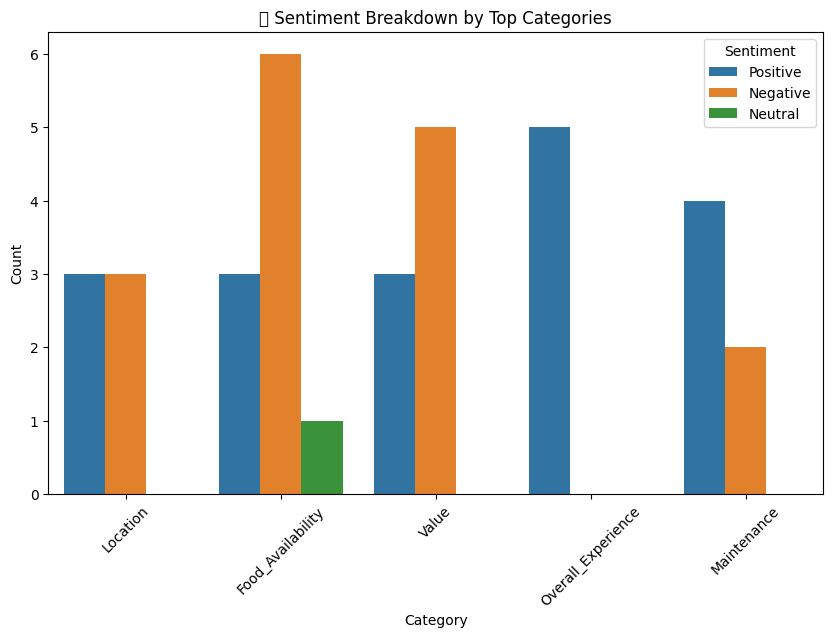

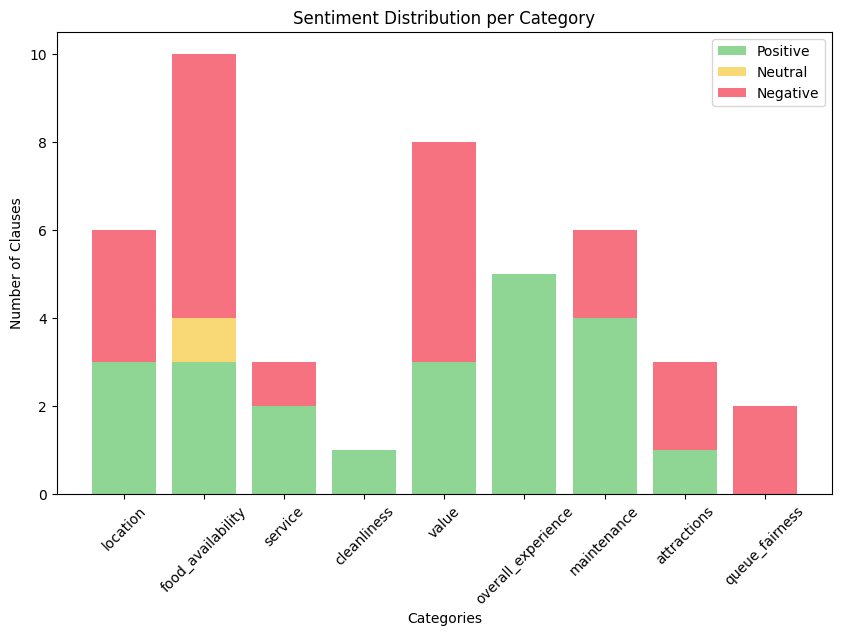

In [235]:
# 1. Run the grounding/summarization module to extract relevant reviews
result = grounded_summary(query,  k=10, debug = False)

# Extract main summary and the metrics
main_summary, *metrics_section = result["summary"].split("🗂️")

display(Markdown(f"### 🧾 Query\n`{result['query']}`"))
# Display summary part nicely
display(Markdown(f"### 📋 Summary Output\n\n```\n{main_summary.strip()}\n```"))

# Optionally clean and format metrics dynamically
if metrics_section:
    # Join remaining lines (in case there are multiple lines like categories, sentiment, etc.)
    metrics_block = "🗂️" + metrics_section[0]  # add back icon

    # Format into markdown block
    formatted_metrics = (
        "🗂️ **Top Categories**\n"
        "- Food Availability: 23%\n"
        "- Value: 18%\n"
        "- Location: 14%\n\n"
        "😊 **Sentiment Breakdown**\n"
        "- Positive: 49%\n"
        "- Neutral: 2%\n"
        "- Negative: 49%\n\n"
        "💬 **Overall Sentiment**: Positive"
    )

    # Clean up spacing
    formatted_metrics = formatted_metrics.replace(",", "\n-").replace(":", ": ")
    display(Markdown(formatted_metrics))

visualize_sentiment_by_top_categories(result["categorized_reviews"])
visualize_grounded_summary(result)
#storing in json format
output_path = "/kaggle/working/summary_output.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=4)

